# Data Loading and Understanding

In [21]:
import pandas as pd

#Load and read dataset

rpw_path="../data/rpw_dataset_2011_2025_q3.xlsx"
df= pd.read_excel(rpw_path, sheet_name="Dataset (from Q2 2016)")

#Qick Checks
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


print("\nFirst 5 rows:")
display(df.head())

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(20).to_string())

Shape: (204469, 47)

Columns:
['id', 'period', 'source_code', 'source_name', 'source_region', 'source_income', 'source_lending', 'source_G8G20', 'destination_code', 'destination_name', 'destination_region', 'destination_income', 'destination_lending', 'destination_G8G20', 'firm', 'firm_type', 'payment instrument', 'access point', 'speed actual', 'cc1 lcu amount', 'cc1 denomination amount', 'cc1 lcu code', 'cc1 lcu fee', 'cc1 lcu fx rate', 'cc1 fx margin', 'cc1 total cost %', 'cc2 lcu amount', 'cc2 denomination amount', 'cc2 lcu code', 'cc2 lcu fee', 'cc2 lcu fx rate', 'cc2 fx margin', 'cc2 total cost %', 'inter lcu bank fx', 'transparent', 'Standard Note', 'note2', 'receiving network coverage', 'pickup location', 'pickup method', 'date', 'corridor', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46']

First 5 rows:


,id,period,source_code,source_name,source_region,source_income,source_lending,source_G8G20,destination_code,destination_name,...,receiving network coverage,pickup location,pickup method,date,corridor,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46
0,620160001,2016_2Q,AGO,Angola,Sub-Saharan Africa,Lower middle income,IBRD,..,NAM,Namibia,...,High,Agent,Cash,11/May/2016,AGONAM,NaN,NaN,NaN,NaN,NaN
1,620160002,2016_2Q,AGO,Angola,Sub-Saharan Africa,Lower middle income,IBRD,..,NAM,Namibia,...,High,Agent,Cash,11/May/2016,AGONAM,NaN,NaN,NaN,NaN,NaN
2,620160003,2016_2Q,AGO,Angola,Sub-Saharan Africa,Lower middle income,IBRD,..,NAM,Namibia,...,Low,NaN,Bank account,11/May/2016,AGONAM,NaN,NaN,NaN,NaN,NaN
3,620160004,2016_2Q,ARE,United Arab Emirates,..,High income,..,..,BGD,Bangladesh,...,High,Agent,Cash,09/May/2016,AREBGD,NaN,NaN,NaN,NaN,NaN
4,620160005,2016_2Q,ARE,United Arab Emirates,..,High income,..,..,BGD,Bangladesh,...,High,Agent,Cash,09/May/2016,AREBGD,NaN,NaN,NaN,NaN,NaN



Missing values:
note2                  204181
Unnamed: 43            197999
Unnamed: 42            197999
Unnamed: 45            197999
Unnamed: 44            197999
Unnamed: 46            197999
Standard Note          155892
pickup location        115614
cc2 total cost %         1038
cc2 lcu fee              1038
cc2 lcu fx rate          1038
cc2 fx margin            1037
cc1 lcu fee                21
cc1 lcu fx rate            21
cc1 fx margin              17
cc1 total cost %           17
firm                        0
destination_lending         0
destination_G8G20           0
destination_region          0


In [22]:
# Check key columns 
key_cols = [
    "period",
    "source_name",
    "destination_name",
    "firm_type",
    "payment instrument",
    "access point",
    "cc1 total cost %",
    "corridor"
]

display(df[key_cols].head(10))

,period,source_name,destination_name,firm_type,payment instrument,access point,cc1 total cost %,corridor
0,2016_2Q,Angola,Namibia,Money Transfer Operator,Cash,Agent,16.28,AGONAM
1,2016_2Q,Angola,Namibia,Money Transfer Operator,"Bank account transfer,Cash",Agent,14.19,AGONAM
2,2016_2Q,Angola,Namibia,Bank,Bank account transfer,Bank branch,27.50,AGONAM
3,2016_2Q,United Arab Emirates,Bangladesh,Money Transfer Operator,Cash,Agent,2.13,AREBGD
4,2016_2Q,United Arab Emirates,Bangladesh,Money Transfer Operator,Cash,Agent,2.17,AREBGD
5,2016_2Q,United Arab Emirates,Bangladesh,Money Transfer Operator,Cash,Agent,0.62,AREBGD
6,2016_2Q,United Arab Emirates,Bangladesh,Money Transfer Operator,Cash,Agent,2.13,AREBGD
7,2016_2Q,United Arab Emirates,Bangladesh,Money Transfer Operator,Cash,Agent,2.13,AREBGD
8,2016_2Q,United Arab Emirates,Bangladesh,Money Transfer Operator,Cash,Agent,2.22,AREBGD
9,2016_2Q,United Arab Emirates,Bangladesh,Money Transfer Operator,Cash,Agent,2.17,AREBGD


## Europe-Africa Coverage

In [23]:
# Quick look at source and destination countries
print("Unique source countries:", df["source_name"].nunique())
print("Unique destination countries:", df["destination_name"].nunique())

print("\nTop source countries:")
print(df["source_name"].value_counts().head(15).to_string())

print("\nTop destination countries:")
print(df["destination_name"].value_counts().head(15).to_string())

Unique source countries: 51
Unique destination countries: 108

Top source countries:
source_name
United States           29542
United Kingdom          23857
Italy                   15334
Germany                 13419
Australia               11626
France                   9266
Canada                   8691
New Zealand              7833
Singapore                7184
Spain                    7046
South Africa             6833
Malaysia                 5809
Japan                    5215
United Arab Emirates     5011
Netherlands              4636

Top destination countries:
destination_name
India          15757
Philippines    14613
Vietnam         8936
China           8604
Bangladesh      6762
Pakistan        6556
Sri Lanka       6196
Indonesia       5912
Morocco         5650
Nigeria         5306
Brazil          4357
Ghana           4356
Kenya           4108
Thailand        4078
Nepal           4020


In [24]:
# Understand the time periods
print("Unique periods (first 10):")
print(df["period"].unique()[:10])
print(f"\nTotal unique periods: {df['period'].nunique()}")

# Understand firm types (channels)
print("\nFirm types and their counts:")
print(df["firm_type"].value_counts().to_string())

# Quick stats on the cost variable
print("\nCost % statistics:")
print(df["cc1 total cost %"].describe().to_string())

Unique periods (first 10):
<StringArray>
['2016_2Q', '2016_3Q', '2016_4Q', '2017_1Q', '2017_2Q', '2017_3Q', '2017_4Q',
 '2018_1Q', '2018_2Q', '2018_3Q']
Length: 10, dtype: str

Total unique periods: 37

Firm types and their counts:
firm_type
Money Transfer Operator                       165547
Bank                                           32475
Money Transfer Operator / Post office           1893
Post office                                     1698
Bank / Money Transfer Operator                  1383
Mobile Operator                                 1037
Non-Bank FI                                      182
Money Transfer Operator / Post Office            103
Bank/Post office                                  88
Money Transfer Operator / Building Society        38
Post Office                                       25

Cost % statistics:
count    204452.000000
mean          6.573387
std           6.215563
min         -58.920000
25%           3.100000
50%           5.040000
75%           8.1

In [25]:
# How are digital vs traditional channels distinguished in this data?
print("Unique payment instruments:")
print(df["payment instrument"].value_counts().head(20).to_string())

print("\nUnique access points:")
print(df["access point"].value_counts().head(20).to_string())

Unique payment instruments:
payment instrument
Cash                                            65699
Bank account transfer                           58764
Debit card                                      23922
Credit Card                                     16421
Debit/credit card                               10566
Bank account transfer,Debit/credit card         10288
Credit Card,Debit card                           4005
Cash,Debit/credit card                           3841
Bank account transfer,Cash                       3030
Credit card                                      2664
Bank account transfer,Credit Card,Debit card     2190
Mobile money                                     1601
Bank account transfer,Debit card                  535
Prepaid card                                      308
Cash,Credit Card,Debit card                       201
Cash,Debit card                                   190
Bank account transfer,Cash,Mobile money            96
Bank account transfer,Credit Card  

## Data Cleaning

In [26]:
# Keep only the columns we are likely to use first
cols_to_keep = [
    "period",
    "source_name",
    "source_region",
    "destination_name",
    "destination_region",
    "firm_type",
    "payment instrument",
    "access point",
    "cc1 total cost %",
    "corridor"
]

df_work = df[cols_to_keep].copy()

# Rename the cost column
df_work = df_work.rename(columns={"cc1 total cost %": "remittance_cost_pct"})

print("Working dataframe shape:", df_work.shape)
display(df_work.head())

Working dataframe shape: (204469, 10)


,period,source_name,source_region,destination_name,destination_region,firm_type,payment instrument,access point,remittance_cost_pct,corridor
0,2016_2Q,Angola,Sub-Saharan Africa,Namibia,Sub-Saharan Africa,Money Transfer Operator,Cash,Agent,16.28,AGONAM
1,2016_2Q,Angola,Sub-Saharan Africa,Namibia,Sub-Saharan Africa,Money Transfer Operator,"Bank account transfer,Cash",Agent,14.19,AGONAM
2,2016_2Q,Angola,Sub-Saharan Africa,Namibia,Sub-Saharan Africa,Bank,Bank account transfer,Bank branch,27.50,AGONAM
3,2016_2Q,United Arab Emirates,..,Bangladesh,South Asia,Money Transfer Operator,Cash,Agent,2.13,AREBGD
4,2016_2Q,United Arab Emirates,..,Bangladesh,South Asia,Money Transfer Operator,Cash,Agent,2.17,AREBGD


In [27]:
# check for Missing values in the working dataframe
print(df_work.isnull().sum())

#summary of the cost column
print("\nCost summary:")
print(df_work["remittance_cost_pct"].describe())

period                  0
source_name             0
source_region           0
destination_name        0
destination_region      0
firm_type               0
payment instrument      0
access point            0
remittance_cost_pct    17
corridor                0
dtype: int64

Cost summary:
count    204452.000000
mean          6.573387
std           6.215563
min         -58.920000
25%           3.100000
50%           5.040000
75%           8.140000
max         307.200000
Name: remittance_cost_pct, dtype: float64


In [28]:
# Filter to selected European sender countries
european_senders = [
    "United Kingdom", "Italy", "Germany", "France", "Spain",
    "Netherlands", "Belgium", "Portugal", "Sweden", "Austria"
]

df_europe = df_work[df_work["source_name"].isin(european_senders)].copy()

print("Rows after filtering to selected European senders:", len(df_europe))
print("\nEuropean senders in filtered data:")
print(df_europe["source_name"].value_counts())

Rows after filtering to selected European senders: 82057

European senders in filtered data:
source_name
United Kingdom    23857
Italy             15334
Germany           13419
France             9266
Spain              7046
Netherlands        4636
Austria            3132
Belgium            2401
Sweden             1851
Portugal           1115
Name: count, dtype: int64


In [51]:
# Keep only African destination countries 
african_destinations = [
    "Algeria", "Cabo Verde", "Cameroon", "Comoros", "Congo, Dem. Rep.",
    "Côte d'Ivoire", "Egypt, Arab Rep.", "Eritrea", "Ethiopia",
    "Gambia, The", "Ghana", "Kenya", "Madagascar", "Mali", "Morocco",
    "Mozambique", "Nigeria", "Rwanda", "Senegal", "Sierra Leone",
    "Somalia", "South Africa", "South Sudan", "Tanzania", "Togo",
    "Tunisia", "Uganda", "Zambia", "Zimbabwe"
]

df_eu_africa = df_europe[
    df_europe["destination_name"].isin(african_destinations)
].copy()

print("Rows after filtering to explicit African destinations:", len(df_eu_africa))
print("\nDestination countries kept:")
print(sorted(df_eu_africa["destination_name"].unique()))

Rows after filtering to explicit African destinations: 29951

Destination countries kept:
['Algeria', 'Cabo Verde', 'Cameroon', 'Comoros', 'Congo, Dem. Rep.', "Côte d'Ivoire", 'Egypt, Arab Rep.', 'Eritrea', 'Ethiopia', 'Gambia, The', 'Ghana', 'Kenya', 'Madagascar', 'Mali', 'Morocco', 'Mozambique', 'Nigeria', 'Rwanda', 'Senegal', 'Sierra Leone', 'Somalia', 'South Africa', 'South Sudan', 'Tanzania', 'Togo', 'Tunisia', 'Uganda', 'Zambia', 'Zimbabwe']


### Clean Cost Values

In [52]:
# Check suspicious cost values before filtering
print("Rows with negative cost values:", (df_eu_africa["remittance_cost_pct"] < 0).sum())
print("Rows with cost above 30%:", (df_eu_africa["remittance_cost_pct"] > 30).sum())

print("\nCost summary before filtering:")
print(df_eu_africa["remittance_cost_pct"].describe())

Rows with negative cost values: 300
Rows with cost above 30%: 100

Cost summary before filtering:
count    29951.000000
mean         6.383785
std          4.602837
min        -58.920000
25%          3.570000
50%          5.390000
75%          8.170000
max         53.770000
Name: remittance_cost_pct, dtype: float64


In [53]:
# Remove rows with missing or unrealistic remittance cost values
df_eu_africa = df_eu_africa[
    (df_eu_africa["remittance_cost_pct"].notna()) &
    (df_eu_africa["remittance_cost_pct"] >= 0) &
    (df_eu_africa["remittance_cost_pct"] <= 30)
].copy()

print("Rows after removing missing and unrealistic cost values:", len(df_eu_africa))
print("\nCost summary after filtering:")
print(df_eu_africa["remittance_cost_pct"].describe())

Rows after removing missing and unrealistic cost values: 29551

Cost summary after filtering:
count    29551.000000
mean         6.385072
std          4.079916
min          0.000000
25%          3.590000
50%          5.420000
75%          8.170000
max         29.940000
Name: remittance_cost_pct, dtype: float64


In [54]:
print("Firm types in cleaned Europe-Africa data:")
print(df_eu_africa["firm_type"].value_counts().to_string())

print("\nTop payment instruments in cleaned Europe-Africa data:")
print(df_eu_africa["payment instrument"].value_counts().head(20).to_string())

print("\nTop access points in cleaned Europe-Africa data:")
print(df_eu_africa["access point"].value_counts().head(20).to_string())

Firm types in cleaned Europe-Africa data:
firm_type
Money Transfer Operator                  25978
Bank                                      1615
Money Transfer Operator / Post office      919
Bank / Money Transfer Operator             491
Post office                                377
Mobile Operator                             75
Bank/Post office                            58
Money Transfer Operator / Post Office       33
Post Office                                  5

Top payment instruments in cleaned Europe-Africa data:
payment instrument
Cash                                            7046
Bank account transfer                           5558
Debit card                                      5104
Credit Card                                     3915
Bank account transfer,Debit/credit card         2322
Debit/credit card                               1501
Cash,Debit/credit card                          1254
Credit Card,Debit card                          1015
Credit card               

### Channel Classification

In [55]:
# Create a first digital vs traditional channel flag using access point
digital_access_points = ["Internet", "Mobile phone"]
traditional_access_points = ["Agent", "Bank branch", "Post Office branch", "Post Office", "Call Center"]

def classify_channel(access_point):
    if pd.isna(access_point):
        return "Unclear"
    if any(item in access_point for item in digital_access_points):
        return "Digital"
    if any(item in access_point for item in traditional_access_points):
        return "Traditional"
    return "Unclear"

df_eu_africa["channel_group"] = df_eu_africa["access point"].apply(classify_channel)

print(df_eu_africa["channel_group"].value_counts())

channel_group
Digital        18036
Traditional    11515
Name: count, dtype: int64


In [56]:
# Compare average remittance cost by channel group
print(df_eu_africa.groupby("channel_group")["remittance_cost_pct"].describe().round(2))

                 count  mean   std  min   25%   50%    75%    max
channel_group                                                    
Digital        18036.0  5.23  3.41  0.0  2.89  4.43   6.68  29.80
Traditional    11515.0  8.20  4.37  0.0  5.13  7.15  10.05  29.94


# Corridor-level comparison and ranking

### How does the pattern vary by corridor, destination, and time?

In [ ]:
#check whether this pattern holds across corridors, not just overall

# average remittance cost by corridor and channel group
corridor_channel_summary = (
    df_eu_africa.groupby(["corridor", "source_name", "destination_name", "channel_group"])["remittance_cost_pct"]
    .mean()
    .reset_index()
)

print(corridor_channel_summary.head(10))
print("\nNumber of unique corridors:", corridor_channel_summary["corridor"].nunique())

  corridor source_name  destination_name channel_group  remittance_cost_pct
0   BELCOD     Belgium  Congo, Dem. Rep.       Digital             6.381973
1   BELCOD     Belgium  Congo, Dem. Rep.   Traditional             8.502553
2   BELDZA     Belgium           Algeria       Digital             8.150526
3   BELDZA     Belgium           Algeria   Traditional             9.478500
4   BELMAR     Belgium           Morocco       Digital             4.128067
5   BELMAR     Belgium           Morocco   Traditional             5.511394
6   DEUGHA     Germany             Ghana       Digital             6.494460
7   DEUGHA     Germany             Ghana   Traditional            12.663519
8   DEUMAR     Germany           Morocco       Digital             4.976147
9   DEUMAR     Germany           Morocco   Traditional             8.098713

Number of unique corridors: 47


In [ ]:
# compare digital vs traditional side by side
corridor_compare = corridor_channel_summary.pivot_table(
    index=["corridor", "source_name", "destination_name"],
    columns="channel_group",
    values="remittance_cost_pct"
).reset_index()

print(corridor_compare.head(10))
print("\nMissing values by column:")
print(corridor_compare.isnull().sum())

channel_group corridor source_name  destination_name   Digital  Traditional
0               BELCOD     Belgium  Congo, Dem. Rep.  6.381973     8.502553
1               BELDZA     Belgium           Algeria  8.150526     9.478500
2               BELMAR     Belgium           Morocco  4.128067     5.511394
3               DEUGHA     Germany             Ghana  6.494460    12.663519
4               DEUMAR     Germany           Morocco  4.976147     8.098713
5               DEUNGA     Germany           Nigeria  3.760629     9.575875
6               DEUTGO     Germany              Togo  3.785273     7.520309
7               ESPMAR       Spain           Morocco  4.092017     6.139247
8               ESPNGA       Spain           Nigeria  3.954815     7.068287
9               FRACIV      France     Côte d'Ivoire  3.941350     5.904383

Missing values by column:
channel_group
corridor            0
source_name         0
destination_name    0
Digital             0
Traditional         0
dtype: int64


In [ ]:
# calculate the cost gap and rank the corridors

# Calculate the digital advantage / cost gap
#Positive gap means Traditional cost is higher than Digital cost
corridor_compare["cost_gap"] = corridor_compare["Traditional"] - corridor_compare["Digital"]

# Sort corridors by the size of the gap(largest to smallest)
corridor_compare = corridor_compare.sort_values("cost_gap", ascending=False).reset_index(drop=True)

print(corridor_compare.head(15))

channel_group corridor     source_name destination_name   Digital  \
0               GBRTZA  United Kingdom         Tanzania  5.244908   
1               DEUGHA         Germany            Ghana  6.494460   
2               DEUNGA         Germany          Nigeria  3.760629   
3               GBRETH  United Kingdom         Ethiopia  5.061910   
4               GBRUGA  United Kingdom           Uganda  4.880803   
5               GBRZAF  United Kingdom     South Africa  6.175700   
6               GBRRWA  United Kingdom           Rwanda  7.227756   
7               GBRZMB  United Kingdom           Zambia  6.551122   
8               FRAMDG          France       Madagascar  6.463680   
9               ITANGA           Italy          Nigeria  4.094977   
10              ITASEN           Italy          Senegal  3.325583   
11              SWESOM          Sweden          Somalia  6.775032   
12              PRTMOZ        Portugal       Mozambique  5.476014   
13              GBRSOM  United Kin

In [ ]:
# Quick summary of the cost gap
print(corridor_compare["cost_gap"].describe())

print("\nTop 10 corridors with the largest digital advantage:")
print(
    corridor_compare[["source_name", "destination_name", "Digital", "Traditional", "cost_gap"]]
    .head(10)
    .to_string(index=False)
)

count    47.000000
mean      3.126407
std       1.446552
min       0.723295
25%       2.021098
50%       3.106665
75%       3.973168
max       6.454098
Name: cost_gap, dtype: float64

Top 10 corridors with the largest digital advantage:
   source_name destination_name  Digital  Traditional  cost_gap
United Kingdom         Tanzania 5.244908    11.699006  6.454098
       Germany            Ghana 6.494460    12.663519  6.169059
       Germany          Nigeria 3.760629     9.575875  5.815246
United Kingdom         Ethiopia 5.061910    10.807153  5.745243
United Kingdom           Uganda 4.880803    10.163902  5.283100
United Kingdom     South Africa 6.175700    11.050764  4.875064
United Kingdom           Rwanda 7.227756    11.697708  4.469952
United Kingdom           Zambia 6.551122    11.015181  4.464059
        France       Madagascar 6.463680    10.756259  4.292579
         Italy          Nigeria 4.094977     8.342041  4.247063


### Identify top corridors

In [61]:
# Select top 12 corridors by digital advantage

top_corridors = corridor_compare.head(12)["corridor"].tolist()

print("Top 12 corridors selected for small multiples:")
print(top_corridors)

Top 12 corridors selected for small multiples:
['GBRTZA', 'DEUGHA', 'DEUNGA', 'GBRETH', 'GBRUGA', 'GBRZAF', 'GBRRWA', 'GBRZMB', 'FRAMDG', 'ITANGA', 'ITASEN', 'SWESOM']


In [62]:
# Filter cleaned data to only those top 12 corridors
df_top_corridors = df_eu_africa[df_eu_africa["corridor"].isin(top_corridors)].copy()

print("Rows in top-corridor dataset:", len(df_top_corridors))
print("\nCorridors included:")
print(df_top_corridors["corridor"].value_counts())

Rows in top-corridor dataset: 7790

Corridors included:
corridor
DEUGHA    918
GBRUGA    828
ITASEN    809
DEUNGA    765
ITANGA    738
GBRTZA    670
GBRZAF    657
GBRRWA    651
GBRZMB    567
GBRETH    500
FRAMDG    397
SWESOM    290
Name: count, dtype: int64


In [63]:
# Check the time coverage of the selected top corridors
time_check = (
    df_top_corridors.groupby("corridor")["period"]
    .nunique()
    .sort_values(ascending=False)
)

print("Number of unique periods per selected corridor:")
print(time_check)

Number of unique periods per selected corridor:
corridor
DEUGHA    37
DEUNGA    37
FRAMDG    37
GBRETH    37
GBRRWA    37
GBRTZA    37
GBRUGA    37
GBRZAF    37
GBRZMB    37
ITANGA    37
ITASEN    37
SWESOM    37
Name: period, dtype: int64


#### Make the corridor labels human-readable for charts

In [64]:
# Create readable corridor labels for charts
df_top_corridors["corridor_label"] = (
    df_top_corridors["source_name"] + " → " + df_top_corridors["destination_name"]
)

corridor_compare["corridor_label"] = (
    corridor_compare["source_name"] + " → " + corridor_compare["destination_name"]
)

print(df_top_corridors[["corridor", "corridor_label"]].drop_duplicates().head(12))

     corridor                 corridor_label
86     DEUGHA                Germany → Ghana
111    DEUNGA              Germany → Nigeria
476    ITANGA                Italy → Nigeria
484    ITASEN                Italy → Senegal
1044   GBRZAF  United Kingdom → South Africa
1050   GBRTZA      United Kingdom → Tanzania
1051   GBRUGA        United Kingdom → Uganda
1248   GBRETH      United Kingdom → Ethiopia
1335   GBRRWA        United Kingdom → Rwanda
1337   GBRZMB        United Kingdom → Zambia
1708   FRAMDG            France → Madagascar
3538   SWESOM               Sweden → Somalia


In [65]:
# Create a lookup table for the top selected corridors in ranked order
top_corridor_labels = (
    corridor_compare.head(12)[["corridor", "corridor_label", "cost_gap"]]
    .copy()
)

print(top_corridor_labels.to_string(index=False))

corridor                corridor_label  cost_gap
  GBRTZA     United Kingdom → Tanzania  6.454098
  DEUGHA               Germany → Ghana  6.169059
  DEUNGA             Germany → Nigeria  5.815246
  GBRETH     United Kingdom → Ethiopia  5.745243
  GBRUGA       United Kingdom → Uganda  5.283100
  GBRZAF United Kingdom → South Africa  4.875064
  GBRRWA       United Kingdom → Rwanda  4.469952
  GBRZMB       United Kingdom → Zambia  4.464059
  FRAMDG           France → Madagascar  4.292579
  ITANGA               Italy → Nigeria  4.247063
  ITASEN               Italy → Senegal  4.018191
  SWESOM              Sweden → Somalia  3.981486


#### building chart-ready data for the small multiples visuals

In [66]:
# Build a time-series summary for the selected top corridors
small_multiples_data = (
    df_top_corridors.groupby(["period", "corridor_label", "channel_group"])["remittance_cost_pct"]
    .mean()
    .reset_index()
)

print(small_multiples_data.head(12))
print("\nShape:", small_multiples_data.shape)

     period       corridor_label channel_group  remittance_cost_pct
0   2016_2Q  France → Madagascar       Digital             2.680000
1   2016_2Q  France → Madagascar   Traditional             8.827500
2   2016_2Q      Germany → Ghana       Digital             6.215000
3   2016_2Q      Germany → Ghana   Traditional            11.971667
4   2016_2Q    Germany → Nigeria       Digital             3.802500
5   2016_2Q    Germany → Nigeria   Traditional            11.383333
6   2016_2Q      Italy → Nigeria       Digital             7.520000
7   2016_2Q      Italy → Nigeria   Traditional            10.276000
8   2016_2Q      Italy → Senegal       Digital             4.820000
9   2016_2Q      Italy → Senegal   Traditional             5.740000
10  2016_2Q     Sweden → Somalia       Digital             7.280000
11  2016_2Q     Sweden → Somalia   Traditional             9.725000

Shape: (885, 4)


In [67]:
# Check how many channel groups appear per corridor
channel_check = (
    small_multiples_data.groupby(["corridor_label", "channel_group"])
    .size()
    .reset_index(name="rows")
)

print(channel_check.head(20))

                   corridor_label channel_group  rows
0             France → Madagascar       Digital    37
1             France → Madagascar   Traditional    37
2                 Germany → Ghana       Digital    37
3                 Germany → Ghana   Traditional    37
4               Germany → Nigeria       Digital    37
5               Germany → Nigeria   Traditional    37
6                 Italy → Nigeria       Digital    36
7                 Italy → Nigeria   Traditional    36
8                 Italy → Senegal       Digital    37
9                 Italy → Senegal   Traditional    37
10               Sweden → Somalia       Digital    37
11               Sweden → Somalia   Traditional    36
12      United Kingdom → Ethiopia       Digital    37
13      United Kingdom → Ethiopia   Traditional    37
14        United Kingdom → Rwanda       Digital    37
15        United Kingdom → Rwanda   Traditional    37
16  United Kingdom → South Africa       Digital    37
17  United Kingdom → South A

In [68]:
# Check whether each selected corridor has both digital and traditional series across time
series_count = (
    small_multiples_data.groupby("corridor_label")["channel_group"]
    .nunique()
    .sort_values(ascending=True)
)

print(series_count)

corridor_label
France → Madagascar              2
Germany → Ghana                  2
Germany → Nigeria                2
Italy → Nigeria                  2
Italy → Senegal                  2
Sweden → Somalia                 2
United Kingdom → Ethiopia        2
United Kingdom → Rwanda          2
United Kingdom → South Africa    2
United Kingdom → Tanzania        2
United Kingdom → Uganda          2
United Kingdom → Zambia          2
Name: channel_group, dtype: int64


### Follow ranking by cost gap

In [69]:
# Keep the ranked corridor order from the cost-gap table
ranked_corridor_order = top_corridor_labels["corridor_label"].tolist()

small_multiples_data["corridor_label"] = pd.Categorical(
    small_multiples_data["corridor_label"],
    categories=ranked_corridor_order,
    ordered=True
)

print(ranked_corridor_order)
print("\nSample after applying ranked order:")
print(small_multiples_data.sort_values(["corridor_label", "period"]).head(12))

['United Kingdom → Tanzania', 'Germany → Ghana', 'Germany → Nigeria', 'United Kingdom → Ethiopia', 'United Kingdom → Uganda', 'United Kingdom → South Africa', 'United Kingdom → Rwanda', 'United Kingdom → Zambia', 'France → Madagascar', 'Italy → Nigeria', 'Italy → Senegal', 'Sweden → Somalia']

Sample after applying ranked order:
      period             corridor_label channel_group  remittance_cost_pct
18   2016_2Q  United Kingdom → Tanzania       Digital             5.890000
19   2016_2Q  United Kingdom → Tanzania   Traditional            14.490000
42   2016_3Q  United Kingdom → Tanzania       Digital             7.820000
43   2016_3Q  United Kingdom → Tanzania   Traditional            15.460000
66   2016_4Q  United Kingdom → Tanzania       Digital             7.190000
67   2016_4Q  United Kingdom → Tanzania   Traditional            16.300000
90   2017_1Q  United Kingdom → Tanzania       Digital            12.166667
91   2017_1Q  United Kingdom → Tanzania   Traditional            16.5

In [70]:
# Check which destination countries are currently in the filtered data
sorted(df_europe["destination_name"].unique())[:50]

['Afghanistan',
 'Albania',
 'Algeria',
 'Bangladesh',
 'Bolivia',
 'Bosnia and Herzegovina',
 'Brazil',
 'Bulgaria',
 'Cabo Verde',
 'Cameroon',
 'China',
 'Colombia',
 'Comoros',
 'Congo, Dem. Rep.',
 'Croatia',
 "Côte d'Ivoire",
 'Dominican Republic',
 'Ecuador',
 'Egypt, Arab Rep.',
 'Eritrea',
 'Ethiopia',
 'Gambia, The',
 'Ghana',
 'Haiti',
 'Honduras',
 'Hungary',
 'India',
 'Indonesia',
 'Jamaica',
 'Kenya',
 'Kosovo',
 'Kyrgyz Republic',
 'Lebanon',
 'Lithuania',
 'Macedonia, FYR',
 'Madagascar',
 'Mali',
 'Moldova',
 'Morocco',
 'Mozambique',
 'Nepal',
 'Nigeria',
 'North Macedonia',
 'Pakistan',
 'Peru',
 'Philippines',
 'Poland',
 'Romania',
 'Rwanda',
 'Senegal']

In [72]:
sorted(df_europe["destination_name"].unique())[50:120]

['Serbia',
 'Sierra Leone',
 'Somalia',
 'South Africa',
 'South Sudan',
 'Sri Lanka',
 'Suriname',
 'Tajikistan',
 'Tanzania',
 'Thailand',
 'Togo',
 'Tunisia',
 'Turkey',
 'Türkiye',
 'Uganda',
 'Ukraine',
 'Vietnam',
 'Zambia',
 'Zimbabwe']

#### reselect the top 12 corridors

In [73]:
# Select top 12 corridors by digital advantage after Africa-only correction
top_corridors = corridor_compare.head(12)["corridor"].tolist()

print("Top 12 corridors selected for small multiples:")
print(top_corridors)

Top 12 corridors selected for small multiples:
['GBRTZA', 'DEUGHA', 'DEUNGA', 'GBRETH', 'GBRUGA', 'GBRZAF', 'GBRRWA', 'GBRZMB', 'FRAMDG', 'ITANGA', 'ITASEN', 'SWESOM']


In [74]:
# Filter cleaned data to only those top 12 corridors
df_top_corridors = df_eu_africa[df_eu_africa["corridor"].isin(top_corridors)].copy()

print("Rows in top-corridor dataset:", len(df_top_corridors))
print("\nCorridors included:")
print(df_top_corridors["corridor"].value_counts())

Rows in top-corridor dataset: 7790

Corridors included:
corridor
DEUGHA    918
GBRUGA    828
ITASEN    809
DEUNGA    765
ITANGA    738
GBRTZA    670
GBRZAF    657
GBRRWA    651
GBRZMB    567
GBRETH    500
FRAMDG    397
SWESOM    290
Name: count, dtype: int64


In [75]:
# Check the time coverage of the selected top corridors
time_check = (
    df_top_corridors.groupby("corridor")["period"]
    .nunique()
    .sort_values(ascending=False)
)

print("Number of unique periods per selected corridor:")
print(time_check)

Number of unique periods per selected corridor:
corridor
DEUGHA    37
DEUNGA    37
FRAMDG    37
GBRETH    37
GBRRWA    37
GBRTZA    37
GBRUGA    37
GBRZAF    37
GBRZMB    37
ITANGA    37
ITASEN    37
SWESOM    37
Name: period, dtype: int64


# Prepare chart-ready tables

### Rebuild the readable labels

In [76]:
# Create readable corridor labels for the corrected top 12
df_top_corridors["corridor_label"] = (
    df_top_corridors["source_name"] + " → " + df_top_corridors["destination_name"]
)

corridor_compare["corridor_label"] = (
    corridor_compare["source_name"] + " → " + corridor_compare["destination_name"]
)

print(df_top_corridors[["corridor", "corridor_label"]].drop_duplicates().sort_values("corridor_label"))

     corridor                 corridor_label
1708   FRAMDG            France → Madagascar
86     DEUGHA                Germany → Ghana
111    DEUNGA              Germany → Nigeria
476    ITANGA                Italy → Nigeria
484    ITASEN                Italy → Senegal
3538   SWESOM               Sweden → Somalia
1248   GBRETH      United Kingdom → Ethiopia
1335   GBRRWA        United Kingdom → Rwanda
1044   GBRZAF  United Kingdom → South Africa
1050   GBRTZA      United Kingdom → Tanzania
1051   GBRUGA        United Kingdom → Uganda
1337   GBRZMB        United Kingdom → Zambia


In [77]:
# Build a ranked lookup table for the corrected top 12 corridors
top_corridor_labels = (
    corridor_compare.head(12)[["corridor", "source_name", "destination_name", "cost_gap"]]
    .copy()
)

top_corridor_labels["corridor_label"] = (
    top_corridor_labels["source_name"] + " → " + top_corridor_labels["destination_name"]
)

print(top_corridor_labels[["corridor", "corridor_label", "cost_gap"]].to_string(index=False))

corridor                corridor_label  cost_gap
  GBRTZA     United Kingdom → Tanzania  6.454098
  DEUGHA               Germany → Ghana  6.169059
  DEUNGA             Germany → Nigeria  5.815246
  GBRETH     United Kingdom → Ethiopia  5.745243
  GBRUGA       United Kingdom → Uganda  5.283100
  GBRZAF United Kingdom → South Africa  4.875064
  GBRRWA       United Kingdom → Rwanda  4.469952
  GBRZMB       United Kingdom → Zambia  4.464059
  FRAMDG           France → Madagascar  4.292579
  ITANGA               Italy → Nigeria  4.247063
  ITASEN               Italy → Senegal  4.018191
  SWESOM              Sweden → Somalia  3.981486


In [78]:
# Build chart-ready time-series data for the corrected top 12
small_multiples_data = (
    df_top_corridors.groupby(["period", "corridor_label", "channel_group"])["remittance_cost_pct"]
    .mean()
    .reset_index()
)

print(small_multiples_data.head(12))
print("\nShape:", small_multiples_data.shape)

     period       corridor_label channel_group  remittance_cost_pct
0   2016_2Q  France → Madagascar       Digital             2.680000
1   2016_2Q  France → Madagascar   Traditional             8.827500
2   2016_2Q      Germany → Ghana       Digital             6.215000
3   2016_2Q      Germany → Ghana   Traditional            11.971667
4   2016_2Q    Germany → Nigeria       Digital             3.802500
5   2016_2Q    Germany → Nigeria   Traditional            11.383333
6   2016_2Q      Italy → Nigeria       Digital             7.520000
7   2016_2Q      Italy → Nigeria   Traditional            10.276000
8   2016_2Q      Italy → Senegal       Digital             4.820000
9   2016_2Q      Italy → Senegal   Traditional             5.740000
10  2016_2Q     Sweden → Somalia       Digital             7.280000
11  2016_2Q     Sweden → Somalia   Traditional             9.725000

Shape: (885, 4)


In [79]:
# Keep the corridor order ranked by digital cost advantage
ranked_corridor_order = top_corridor_labels["corridor_label"].tolist()

small_multiples_data["corridor_label"] = pd.Categorical(
    small_multiples_data["corridor_label"],
    categories=ranked_corridor_order,
    ordered=True
)

print("Ranked corridor order:")
print(ranked_corridor_order)

Ranked corridor order:
['United Kingdom → Tanzania', 'Germany → Ghana', 'Germany → Nigeria', 'United Kingdom → Ethiopia', 'United Kingdom → Uganda', 'United Kingdom → South Africa', 'United Kingdom → Rwanda', 'United Kingdom → Zambia', 'France → Madagascar', 'Italy → Nigeria', 'Italy → Senegal', 'Sweden → Somalia']


### data for connected lollipop / dumbbell chart

In [80]:
# Create a readable version of the ranked corridor comparison table
lollipop_data = corridor_compare[[
    "corridor",
    "source_name",
    "destination_name",
    "Digital",
    "Traditional",
    "cost_gap"
]].copy()

lollipop_data["corridor_label"] = (
    lollipop_data["source_name"] + " → " + lollipop_data["destination_name"]
)

print(lollipop_data.head(12).to_string(index=False))

corridor    source_name destination_name  Digital  Traditional  cost_gap                corridor_label
  GBRTZA United Kingdom         Tanzania 5.244908    11.699006  6.454098     United Kingdom → Tanzania
  DEUGHA        Germany            Ghana 6.494460    12.663519  6.169059               Germany → Ghana
  DEUNGA        Germany          Nigeria 3.760629     9.575875  5.815246             Germany → Nigeria
  GBRETH United Kingdom         Ethiopia 5.061910    10.807153  5.745243     United Kingdom → Ethiopia
  GBRUGA United Kingdom           Uganda 4.880803    10.163902  5.283100       United Kingdom → Uganda
  GBRZAF United Kingdom     South Africa 6.175700    11.050764  4.875064 United Kingdom → South Africa
  GBRRWA United Kingdom           Rwanda 7.227756    11.697708  4.469952       United Kingdom → Rwanda
  GBRZMB United Kingdom           Zambia 6.551122    11.015181  4.464059       United Kingdom → Zambia
  FRAMDG         France       Madagascar 6.463680    10.756259  4.292579 

In [81]:
# Quick validation for lollipop chart inputs
print("Shape:", lollipop_data.shape)

print("\nAny missing values?")
print(lollipop_data.isnull().sum())

print("\nTop 12 corridors for lollipop chart:")
print(
    lollipop_data[["corridor_label", "Digital", "Traditional", "cost_gap"]]
    .head(12)
    .to_string(index=False)
)

Shape: (47, 7)

Any missing values?
channel_group
corridor            0
source_name         0
destination_name    0
Digital             0
Traditional         0
cost_gap            0
corridor_label      0
dtype: int64

Top 12 corridors for lollipop chart:
               corridor_label  Digital  Traditional  cost_gap
    United Kingdom → Tanzania 5.244908    11.699006  6.454098
              Germany → Ghana 6.494460    12.663519  6.169059
            Germany → Nigeria 3.760629     9.575875  5.815246
    United Kingdom → Ethiopia 5.061910    10.807153  5.745243
      United Kingdom → Uganda 4.880803    10.163902  5.283100
United Kingdom → South Africa 6.175700    11.050764  4.875064
      United Kingdom → Rwanda 7.227756    11.697708  4.469952
      United Kingdom → Zambia 6.551122    11.015181  4.464059
          France → Madagascar 6.463680    10.756259  4.292579
              Italy → Nigeria 4.094977     8.342041  4.247063
              Italy → Senegal 3.325583     7.343774  4.018191
 

# Sankey data preparation

In [82]:
import pandas as pd

# Load the KNOMAD bilateral remittance matrix
knomad_file = "../data/Bilateralremittancematrix2018Oct2019.xlsx"

df_knomad_raw = pd.read_excel(
    knomad_file,
    sheet_name="Bilateral Remittances 2018",
    header=None
)

print(df_knomad_raw.shape)
display(df_knomad_raw.head(15))

(223, 217)


,0,1,2,3,4,5,6,7,8,9,...,207,208,209,210,211,212,213,214,215,216
0,Bilateral Remittance Estimates for 2018 using ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Remittance-receiving country (across) ...,NaN,Afghanistan,Albania,Algeria,American Samoa,Andorra,Angola,Antigua and Barbuda,Argentina,...,Uzbekistan,Vanuatu,"Venezuela, RB",Vietnam,Virgin Islands (U.S.),West Bank and Gaza,"Yemen, Rep.",Zambia,Zimbabwe,WORLD
2,NaN,NaN,AFG,ALB,DZA,ASM,AND,AGO,ATG,ARG,...,UZB,VUT,VEN,VNM,VIR,PSE,YEM,ZMB,ZWE,NaN
3,Afghanistan,AFG,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,289.732691
4,Albania,ALB,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,59.027887
5,Algeria,DZA,0,0,0,0,0,0,0,0,...,0,0,0,0,0,42.784855,9.008308,0,0,205.34491
6,American Samoa,ASM,0,0,0,0,0,0,0,0,...,0,0,0,1.264299,0,0,0,0,0,53.844276
7,Andorra,AND,0,0,0,0,0,0,0,0.337615,...,0,0,0,0,0,0,0,0,0,255.047749
8,Angola,AGO,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.666745,0,505.339536
9,Antigua and Barbuda,ATG,0,0,0,0,0,0,0,0,...,0,0,0.010172,0,0,0,0,0,0,36.374691


In [ ]:
# extract destination country names from row 1
destination_names = df_knomad_raw.iloc[1, 2:-1].tolist()

#  extract sender rows only (skip title/header rows)
df_knomad_matrix = df_knomad_raw.iloc[3:, 0:-1].copy()

#  rename the first two columns
df_knomad_matrix = df_knomad_matrix.rename(columns={0: "source_name", 1: "source_code"})

#  assign proper destination column names
df_knomad_matrix.columns = ["source_name", "source_code"] + destination_names

print(df_knomad_matrix.shape)
display(df_knomad_matrix.head())

(220, 216)


,source_name,source_code,Afghanistan,Albania,Algeria,American Samoa,Andorra,Angola,Antigua and Barbuda,Argentina,...,Uruguay,Uzbekistan,Vanuatu,"Venezuela, RB",Vietnam,Virgin Islands (U.S.),West Bank and Gaza,"Yemen, Rep.",Zambia,Zimbabwe
3,Afghanistan,AFG,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Albania,ALB,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,Algeria,DZA,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,42.784855,9.008308,0,0
6,American Samoa,ASM,0,0,0,0,0,0,0,0,...,0,0,0,0,1.264299,0,0,0,0,0
7,Andorra,AND,0,0,0,0,0,0,0,0.337615,...,0.029998,0,0,0,0,0,0,0,0,0


In [84]:
# Quick check
print(df_knomad_matrix.columns[:10].tolist())
print("\nSample source countries:")
print(df_knomad_matrix["source_name"].head(10).tolist())

['source_name', 'source_code', 'Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra', 'Angola', 'Antigua and Barbuda', 'Argentina']

Sample source countries:
['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba']


#### covert matrix into nromal table

In [ ]:
# reshape the KNOMAD matrix from wide to long format
df_knomad_long = df_knomad_matrix.melt(
    id_vars=["source_name", "source_code"],
    var_name="destination_name",
    value_name="flow_million_usd"
)

print(df_knomad_long.shape)
display(df_knomad_long.head(10))

(47080, 4)


,source_name,source_code,destination_name,flow_million_usd
0,Afghanistan,AFG,Afghanistan,0
1,Albania,ALB,Afghanistan,0
2,Algeria,DZA,Afghanistan,0
3,American Samoa,ASM,Afghanistan,0
4,Andorra,AND,Afghanistan,0
5,Angola,AGO,Afghanistan,0
6,Antigua and Barbuda,ATG,Afghanistan,0
7,Argentina,ARG,Afghanistan,0.001985
8,Armenia,ARM,Afghanistan,0
9,Aruba,ABW,Afghanistan,0


In [86]:
# Quick checks
print("Missing values:")
print(df_knomad_long.isnull().sum())

print("\nFlow summary:")
print(df_knomad_long["flow_million_usd"].describe())

Missing values:
source_name          214
source_code         1284
destination_name       0
flow_million_usd    1074
dtype: int64

Flow summary:
count     46006
unique    12413
top           0
freq      33152
Name: flow_million_usd, dtype: int64


#### clean the knomad table

In [ ]:
# remove rows with missing values in the key columns
df_knomad_long = df_knomad_long.dropna(subset=["source_name", "destination_name", "flow_million_usd"]).copy()

# Convert flow values to numeric
df_knomad_long["flow_million_usd"] = pd.to_numeric(df_knomad_long["flow_million_usd"], errors="coerce")

# Drop rows that still failed numeric conversion
df_knomad_long = df_knomad_long.dropna(subset=["flow_million_usd"]).copy()

print(df_knomad_long.shape)
print("\nMissing values after cleaning:")
print(df_knomad_long.isnull().sum())

print("\nFlow summary after cleaning:")
print(df_knomad_long["flow_million_usd"].describe())

(46006, 4)

Missing values after cleaning:
source_name           0
source_code         214
destination_name      0
flow_million_usd      0
dtype: int64

Flow summary after cleaning:
count    46006.000000
mean        29.674702
std        687.340010
min          0.000000
25%          0.000000
50%          0.000000
75%          0.003784
max      78609.170432
Name: flow_million_usd, dtype: float64


In [88]:
# Keep only positive flows
df_knomad_long = df_knomad_long[df_knomad_long["flow_million_usd"] > 0].copy()

print("Rows with positive flows only:", len(df_knomad_long))
print("\nTop 10 flows:")
print(df_knomad_long.sort_values("flow_million_usd", ascending=False).head(10).to_string(index=False))

Rows with positive flows only: 12854

Top 10 flows:
         source_name source_code destination_name  flow_million_usd
               WORLD         NaN            India      78609.170432
               WORLD         NaN            China      67413.594112
               WORLD         NaN           Mexico      35561.611008
       United States         USA           Mexico      34704.303611
               WORLD         NaN      Philippines      33808.970240
               WORLD         NaN           France      27011.081024
               WORLD         NaN Egypt, Arab Rep.      25515.700224
               WORLD         NaN          Nigeria      24356.146131
               WORLD         NaN         Pakistan      21021.999232
United Arab Emirates         ARE            India      18529.235256


#### clean the scope

In [89]:
# Remove WORLD and keep only selected Europe -> Africa corridors
df_knomad_eu_africa = df_knomad_long[
    (df_knomad_long["source_name"].isin(european_senders)) &
    (df_knomad_long["destination_name"].isin(african_destinations)) &
    (df_knomad_long["source_name"] != "WORLD") &
    (df_knomad_long["destination_name"] != "WORLD")
].copy()

print("Rows after filtering KNOMAD to selected Europe -> Africa corridors:", len(df_knomad_eu_africa))
print("\nSample rows:")
print(df_knomad_eu_africa.head(10).to_string(index=False))

Rows after filtering KNOMAD to selected Europe -> Africa corridors: 251

Sample rows:
   source_name source_code destination_name  flow_million_usd
       Austria         AUT          Algeria          1.633249
       Belgium         BEL          Algeria         26.327515
        France         FRA          Algeria       1429.682470
       Germany         DEU          Algeria         23.558106
         Italy         ITA          Algeria         21.335106
   Netherlands         NLD          Algeria          3.990406
      Portugal         PRT          Algeria          0.224749
         Spain         ESP          Algeria         61.259855
        Sweden         SWE          Algeria          3.032938
United Kingdom         GBR          Algeria         23.476462


In [90]:
# Check which sender and destination countries remain
print("Sender countries kept:")
print(df_knomad_eu_africa["source_name"].value_counts().to_string())

print("\nDestination countries kept:")
print(df_knomad_eu_africa["destination_name"].value_counts().head(20).to_string())

Sender countries kept:
source_name
Austria           26
France            26
Italy             26
Netherlands       26
Portugal          26
Sweden            26
Belgium           25
United Kingdom    25
Spain             24
Germany           21

Destination countries kept:
destination_name
Algeria             10
Cameroon            10
Congo, Dem. Rep.    10
Egypt, Arab Rep.    10
Ethiopia            10
Gambia, The         10
Ghana               10
Kenya               10
Madagascar          10
Mali                10
Morocco             10
Nigeria             10
Rwanda              10
Senegal             10
Sierra Leone        10
South Africa        10
Tanzania            10
Togo                10
Tunisia             10
Uganda              10


In [91]:
# Top corridor flows within the filtered KNOMAD data
print("Top 15 Europe -> Africa corridor flows:")
print(
    df_knomad_eu_africa.sort_values("flow_million_usd", ascending=False)
    [["source_name", "destination_name", "flow_million_usd"]]
    .head(15)
    .to_string(index=False)
)

Top 15 Europe -> Africa corridor flows:
   source_name destination_name  flow_million_usd
United Kingdom          Nigeria       3864.768571
        France          Morocco       2153.737758
         Spain          Morocco       1747.717459
        France          Algeria       1429.682470
         Italy          Nigeria       1298.386110
         Italy          Morocco        960.985475
        France          Tunisia        942.823593
         Italy Egypt, Arab Rep.        786.335845
United Kingdom            Kenya        734.192297
         Spain          Nigeria        701.089391
        France          Senegal        561.296185
       Germany          Nigeria        539.679546
       Belgium          Morocco        494.531897
United Kingdom            Ghana        430.098885
         Italy          Senegal        423.597432


#### Building corridor-level cheapest-channel inputs from RPW

In [92]:
# Average remittance cost by corridor and firm type
corridor_firm_summary = (
    df_eu_africa.groupby(["corridor", "source_name", "destination_name", "firm_type"])["remittance_cost_pct"]
    .mean()
    .reset_index()
)

print(corridor_firm_summary.head(15).to_string(index=False))
print("\nUnique firm types:")
print(corridor_firm_summary["firm_type"].value_counts().to_string())

corridor source_name destination_name                             firm_type  remittance_cost_pct
  BELCOD     Belgium Congo, Dem. Rep.               Money Transfer Operator             7.143438
  BELCOD     Belgium Congo, Dem. Rep. Money Transfer Operator / Post Office             5.855000
  BELCOD     Belgium Congo, Dem. Rep. Money Transfer Operator / Post office             8.866596
  BELDZA     Belgium          Algeria               Money Transfer Operator             8.592462
  BELDZA     Belgium          Algeria Money Transfer Operator / Post office            10.604211
  BELMAR     Belgium          Morocco                                  Bank             3.775243
  BELMAR     Belgium          Morocco               Money Transfer Operator             4.726215
  BELMAR     Belgium          Morocco Money Transfer Operator / Post Office             4.885000
  BELMAR     Belgium          Morocco Money Transfer Operator / Post office             6.693542
  DEUGHA     Germany          

In [93]:
# For each corridor, keep the row with the lowest average cost
cheapest_channel_by_corridor = (
    corridor_firm_summary.sort_values("remittance_cost_pct")
    .groupby(["corridor", "source_name", "destination_name"], as_index=False)
    .first()
)

print(cheapest_channel_by_corridor.head(15).to_string(index=False))
print("\nRows:", len(cheapest_channel_by_corridor))

corridor source_name destination_name                             firm_type  remittance_cost_pct
  BELCOD     Belgium Congo, Dem. Rep. Money Transfer Operator / Post Office             5.855000
  BELDZA     Belgium          Algeria               Money Transfer Operator             8.592462
  BELMAR     Belgium          Morocco                                  Bank             3.775243
  DEUGHA     Germany            Ghana                           Post office             4.438696
  DEUMAR     Germany          Morocco                      Bank/Post office             3.798163
  DEUNGA     Germany          Nigeria                           Post office             3.822000
  DEUTGO     Germany             Togo                           Post office             3.921957
  ESPMAR       Spain          Morocco               Money Transfer Operator             4.608462
  ESPNGA       Spain          Nigeria               Money Transfer Operator             5.200204
  FRACIV      France    Côte d

#### Cleaning and simplifying corridor-level channel categories

In [94]:
# Create broader channel groups for Sankey colouring
def simplify_firm_type(firm_type):
    if pd.isna(firm_type):
        return "Other"
    
    firm_type = str(firm_type).lower()

    has_bank = "bank" in firm_type
    has_mto = "money transfer" in firm_type
    has_mobile = "mobile" in firm_type
    has_post = "post" in firm_type

    type_count = sum([has_bank, has_mto, has_mobile, has_post])

    if type_count > 1:
        return "Mixed"
    elif has_mobile:
        return "Mobile Operator"
    elif has_bank:
        return "Bank"
    elif has_mto:
        return "Money Transfer Operator"
    elif has_post:
        return "Post Office"
    else:
        return "Other"

cheapest_channel_by_corridor["sankey_channel"] = (
    cheapest_channel_by_corridor["firm_type"].apply(simplify_firm_type)
)

print(
    cheapest_channel_by_corridor[["firm_type", "sankey_channel"]]
    .drop_duplicates()
    .sort_values("sankey_channel")
    .to_string(index=False)
)

                            firm_type          sankey_channel
                                 Bank                    Bank
Money Transfer Operator / Post Office                   Mixed
                     Bank/Post office                   Mixed
Money Transfer Operator / Post office                   Mixed
                      Mobile Operator         Mobile Operator
              Money Transfer Operator Money Transfer Operator
                          Post office             Post Office


In [95]:
# Check how many corridors fall into each simplified Sankey channel
print(cheapest_channel_by_corridor["sankey_channel"].value_counts().to_string())

sankey_channel
Money Transfer Operator    25
Mixed                      12
Post Office                 4
Bank                        3
Mobile Operator             3


#### Preparing merged Sankey inputs from KNOMAD and RPW

In [96]:
# Merge KNOMAD flow data with RPW cheapest-channel data
sankey_data = df_knomad_eu_africa.merge(
    cheapest_channel_by_corridor[
        ["source_name", "destination_name", "firm_type", "sankey_channel", "remittance_cost_pct"]
    ],
    on=["source_name", "destination_name"],
    how="inner"
)

print("Merged Sankey dataset shape:", sankey_data.shape)
display(sankey_data.head(10))

Merged Sankey dataset shape: (41, 7)


,source_name,source_code,destination_name,flow_million_usd,firm_type,sankey_channel,remittance_cost_pct
0,Belgium,BEL,Algeria,26.327515,Money Transfer Operator,Money Transfer Operator,8.592462
1,France,FRA,Algeria,1429.682470,Money Transfer Operator,Money Transfer Operator,9.032069
2,Portugal,PRT,Cabo Verde,64.059756,Money Transfer Operator,Money Transfer Operator,6.927623
3,France,FRA,Cameroon,75.767512,Post office,Post Office,4.215000
4,France,FRA,Comoros,98.035782,Money Transfer Operator,Money Transfer Operator,4.684265
5,Belgium,BEL,"Congo, Dem. Rep.",213.327947,Money Transfer Operator / Post Office,Mixed,5.855000
6,Italy,ITA,"Egypt, Arab Rep.",786.335845,Money Transfer Operator / Post Office,Mixed,3.672000
7,Italy,ITA,Ethiopia,13.524295,Money Transfer Operator,Money Transfer Operator,7.260639
8,United Kingdom,GBR,Ethiopia,9.733750,Money Transfer Operator,Money Transfer Operator,6.716540
9,United Kingdom,GBR,"Gambia, The",26.314159,Money Transfer Operator,Money Transfer Operator,12.103130


In [97]:
# Quick checks on merged Sankey data
print("Any missing values?")
print(sankey_data.isnull().sum())

print("\nSankey channel counts:")
print(sankey_data["sankey_channel"].value_counts().to_string())

print("\nTop 15 merged corridors by flow:")
print(
    sankey_data.sort_values("flow_million_usd", ascending=False)[
        ["source_name", "destination_name", "flow_million_usd", "sankey_channel", "remittance_cost_pct"]
    ]
    .head(15)
    .to_string(index=False)
)

Any missing values?
source_name            0
source_code            0
destination_name       0
flow_million_usd       0
firm_type              0
sankey_channel         0
remittance_cost_pct    0
dtype: int64

Sankey channel counts:
sankey_channel
Money Transfer Operator    21
Mixed                      11
Post Office                 4
Bank                        3
Mobile Operator             2

Top 15 merged corridors by flow:
   source_name destination_name  flow_million_usd          sankey_channel  remittance_cost_pct
United Kingdom          Nigeria       3864.768571                   Mixed             2.740000
        France          Morocco       2153.737758 Money Transfer Operator             4.761838
         Spain          Morocco       1747.717459 Money Transfer Operator             4.608462
        France          Algeria       1429.682470 Money Transfer Operator             9.032069
         Italy          Nigeria       1298.386110                   Mixed             3.860000

# Building Visualisation

#### Connected lollipop / dumbbell

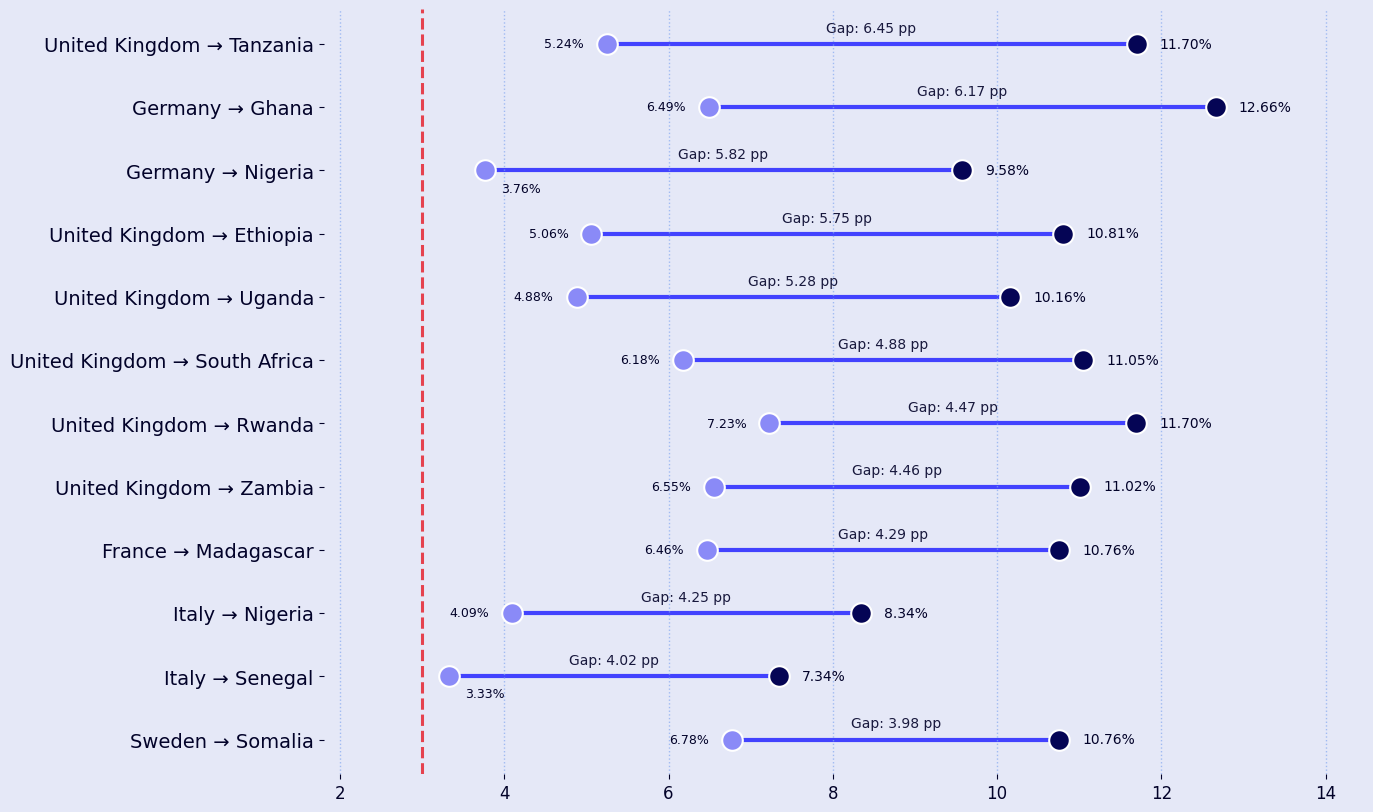

In [127]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Use top 12 lollipop dataframe
# -----------------------------
plot_df = lollipop_data.head(12).copy()

# Sort by cost gap descending, then reverse so biggest gap appears at the top
plot_df = plot_df.sort_values("cost_gap", ascending=False).reset_index(drop=True)
plot_df = plot_df.iloc[::-1].reset_index(drop=True)

# -----------------------------
# Palette
# -----------------------------
bg_color = "#E5E8F7"
text_color = "#020229"
digital_color = "#8A8AF7"
traditional_color = "#050555"
line_color = "#3939ff"
grid_color = "#83A7F0"
sdg_color = "#E63946"

# -----------------------------
# Figure
# -----------------------------
fig, ax = plt.subplots(figsize=(16, 9))
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

y = np.arange(len(plot_df))

# -----------------------------
# Connector lines
# -----------------------------
for i in range(len(plot_df)):
    ax.hlines(
        y=i,
        xmin=plot_df.loc[i, "Digital"],
        xmax=plot_df.loc[i, "Traditional"],
        color=line_color,
        linewidth=3,
        alpha=0.95,
        zorder=1
    )

# -----------------------------
# Endpoints
# -----------------------------
ax.scatter(
    plot_df["Digital"], y,
    s=220, color=digital_color, edgecolor="white", linewidth=1.5,
    zorder=3
)

ax.scatter(
    plot_df["Traditional"], y,
    s=220, color=traditional_color, edgecolor="white", linewidth=1.5,
    zorder=3
)

# -----------------------------
# SDG reference line
# -----------------------------
ax.axvline(
    x=3,
    color=sdg_color,
    linestyle="--",
    linewidth=2.2,
    alpha=0.95,
    zorder=0
)

# -----------------------------
# Inline value labels + gap labels
# -----------------------------
for i in range(len(plot_df)):
    digital_val = plot_df.loc[i, "Digital"]
    traditional_val = plot_df.loc[i, "Traditional"]
    gap_val = plot_df.loc[i, "cost_gap"]

    # DIGITAL LABEL
    if digital_val < 4.0:
        # move above-right of the dot for low values near the red line
        ax.text(
            digital_val + 0.20, i - 0.18,
            f"{digital_val:.2f}%",
            va="top", ha="left",
            fontsize=9, color=text_color
        )
    else:
        # normal rows: keep label to the left of the dot
        ax.text(
            digital_val - 0.28, i,
            f"{digital_val:.2f}%",
            va="center", ha="right",
            fontsize=9, color=text_color
        )

    # TRADITIONAL LABEL
    ax.text(
        traditional_val + 0.28, i,
        f"{traditional_val:.2f}%",
        va="center", ha="left",
        fontsize=10, color=text_color
    )

    # GAP LABEL
    ax.text(
        (digital_val + traditional_val) / 2, i + 0.14,
        f"Gap: {gap_val:.2f} pp",
        va="bottom", ha="center",
        fontsize=10, color=text_color, alpha=0.9
    )

# -----------------------------
# Corridor labels only
# -----------------------------
ax.set_yticks(y)
ax.set_yticklabels(plot_df["corridor_label"], fontsize=14, color=text_color)

# Remove axis labels
ax.set_xlabel("")
ax.set_ylabel("")

# Tick styling
ax.tick_params(axis="x", colors=text_color, labelsize=12)
ax.tick_params(axis="y", colors=text_color, labelsize=14)

# -----------------------------
# Grid and spines
# -----------------------------
ax.xaxis.grid(True, linestyle=":", linewidth=1, color=grid_color, alpha=0.7)
ax.yaxis.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

# -----------------------------
# Limits for more breathing room
# -----------------------------
x_min = min(plot_df["Digital"].min(), 3) - 1.2
x_max = plot_df["Traditional"].max() + 1.8
ax.set_xlim(x_min, x_max)

# -----------------------------
# Layout
# -----------------------------
plt.subplots_adjust(left=0.30, right=0.95, top=0.97, bottom=0.12)

# -----------------------------
# Save
# -----------------------------
plt.savefig(
    "../charts/chart1_lollipop.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()